New point added:      Values
596   187.0
597    88.0
600   350.0
605     NaN
613   133.0
Length of 'N' class: 192
Expected length: 422
230
Std: 0.44919786096256686 Mean: -0.4929732817285628
Initial Deviations: [  0.  -1.  -3.  -8. -17. -17.  45.  23. -14.  -6.  -3.  -3.   2.   1.]
Desired sample size based on max deviation: 612
Deviations after adjusting sample size: [ -1.  -3. -10. -27. -56. -82. -37. -59. -79. -45. -22. -10.   0.   0.]
Fractional Deficits: [1.         1.         1.         1.         1.         0.8909221
 0.31739449 0.50511101 0.85819873 0.80441941 0.81431967 1.
 0.         0.        ]
Adding point -0.0031353598862499943 in range (-0.12307771195915218, 0.10162925483151808)
Sum of fractional deficits for quantiles within range [-1, 1]: 4.281663258477906
Adding point -0.4230207359397241 in range (-0.572192513368984, -0.3475456861944854)
Sum of fractional deficits for quantiles within range [-1, 1]: 4.2731306896627395
Adding point 0.38060292547151375 in range (0.3257886

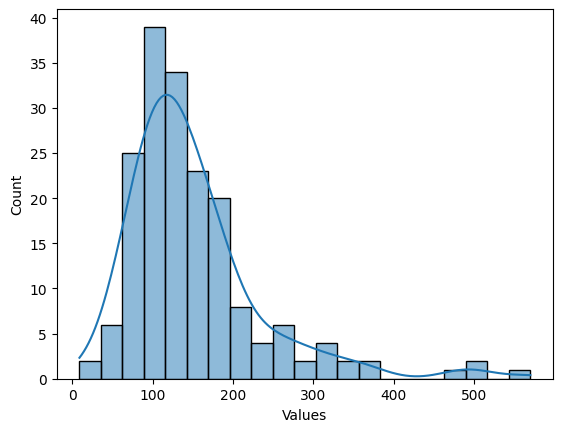

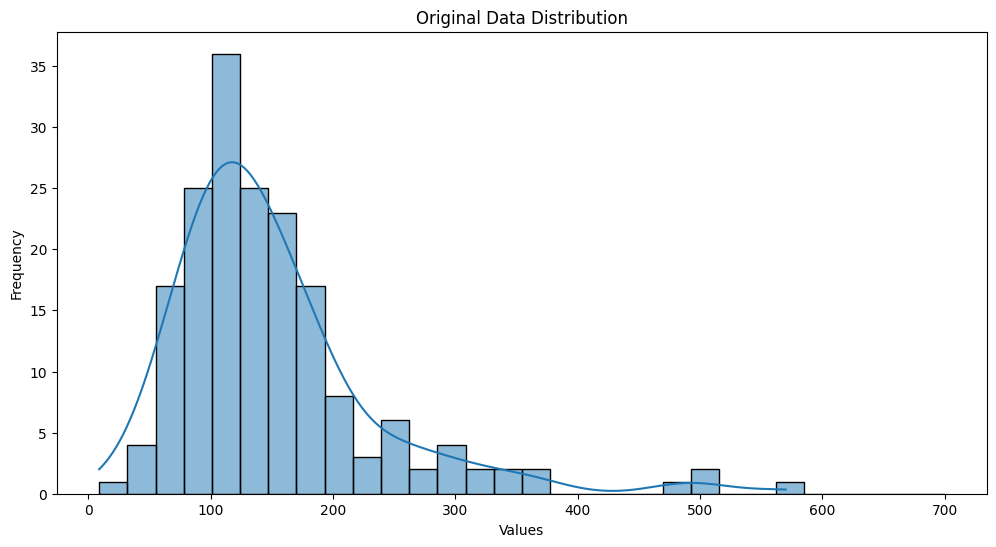

0.8794338406565394
0.6325931251475034


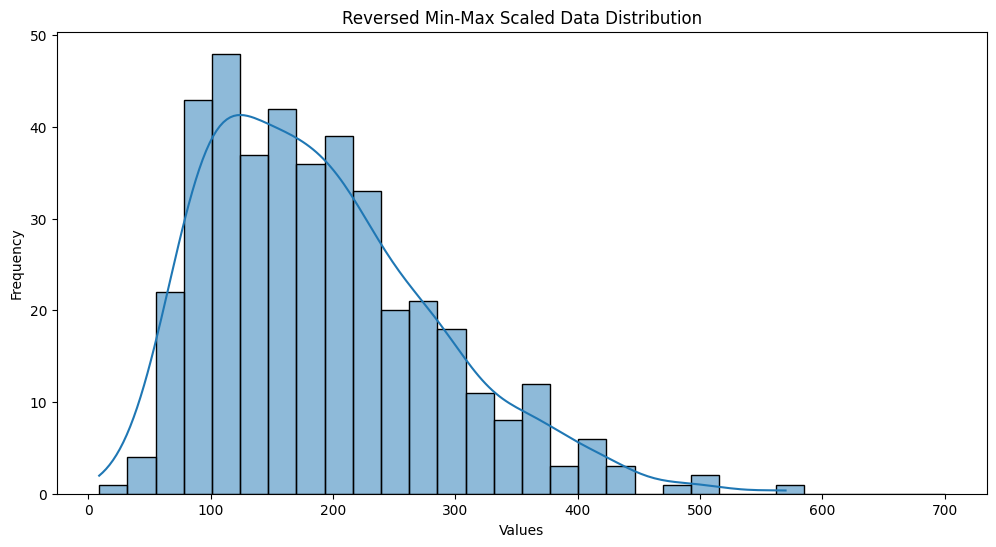

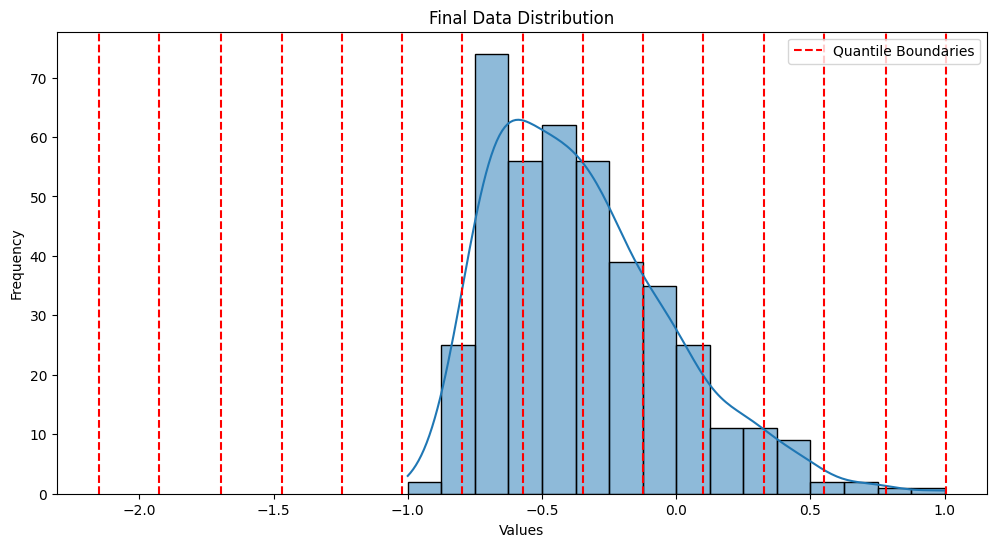

Quantile Boundaries: [-2.14953003 -1.9249311  -1.69543503 -1.47017372 -1.24601428 -1.02130731
 -0.79683934 -0.57219251 -0.34754569 -0.12307771  0.10162925  0.3257887
  0.55105     0.78054607  1.005145  ]
Final Deviations: [ -1.  -3. -10. -27. -56. -82.  -1. -11. -10.  -1.   0.   1.   0.   0.]
Final Data Length: 411


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

# Example Usage
data = pd.read_csv("/content/loan_approved_csv.csv")

# Separate classes
y_class = data[(data['Loan_Status (Approved)'] == 'Y') ]
n_class = data[(data['Loan_Status (Approved)'] == 'N')]
df = pd.DataFrame(n_class, columns=['LoanAmount']).rename(columns={'LoanAmount': 'Values'})
y_class = pd.DataFrame(y_class, columns=['LoanAmount']).rename(columns={'LoanAmount': 'Values'})

# Concatenate the new point to the existing DataFrame
print("New point added:", df.tail())
sns.histplot(df['Values'], kde=True)

expected_length = len(y_class)
print("Length of 'N' class:", len(n_class))
print("Expected length:", expected_length)
diff = expected_length - len(df)
print(diff)

# Ensure Values column is numeric and handle missing values
df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
df = df.dropna()

# Step 1: Min-Max Normalization to range [-1, 1]
if not df.empty:
    df.loc[:,'Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
else:
    raise ValueError("DataFrame 'df' is empty after filtering.")

# Step 2: Define Quartile Boundaries for Normal Distribution
mean = df['Values'].mean()
median = df['Values'].median()
#std =df['Values'].std()
std = (df['Values'].max() - median) / 3.5
print("Std:", std, "Mean:", mean)

# Define the quantile boundaries with appropriate extreme boundaries using percentiles
quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
quantile_boundaries = norm.ppf(quantiles, loc=median, scale=std)

# Calculate extreme boundaries
extreme_low = quantile_boundaries[0] - std / 2
extreme_high = quantile_boundaries[-1] + std / 2

# Concatenate boundaries
quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))

# Ensure boundaries are strictly increasing
quantile_boundaries = np.sort(quantile_boundaries)

# Step 3: Find Deviations
def quantile_deviation(data, length_data, boundaries, expected_percentages):
    observed_counts = np.histogram(data, bins=boundaries)[0]
    expected_counts = expected_percentages * length_data
    deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
    return deviations, expected_counts, observed_counts

# Make sure expected_percentages matches the number of bins (number of boundaries - 1)
expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100

# Calculate deviations
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], len(df['Values']), quantile_boundaries, expected_percentages)
print("Initial Deviations:", deviations)

# Step 4: Adjust Sample Size
n = len(df)
max_deviation = np.max(deviations)
while max_deviation != 0:
    max_deviation_idx = np.argmax(deviations)
    max_deviation = deviations[max_deviation_idx]
    if (max_deviation > 0):
        n = observed_counts[max_deviation_idx] / expected_percentages[max_deviation_idx]
        n = int(np.round(n))
    else:
        break
    deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)

print("Desired sample size based on max deviation:", n)


# Step 6: Calculate Final Deviations and Metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
deviation_strengths = observed_counts / expected_counts
fractional_deficits = 1 - deviation_strengths
fractional_deficits[fractional_deficits < 0] = 0
print("Deviations after adjusting sample size:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
points_remaining = diff
while points_remaining > 0:
    # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
    valid_indices = (quantile_boundaries[:-1] >= -1) & (quantile_boundaries[1:] <= 1)
    valid_fractional_deficits = fractional_deficits[valid_indices]
    valid_boundaries_start = quantile_boundaries[:-1][valid_indices]
    valid_boundaries_end = quantile_boundaries[1:][valid_indices]

    # Check if valid_fractional_deficits sum is zero to avoid division by zero
    if (valid_fractional_deficits.sum() == 0):
        # When all probabilities are zero, distribute points evenly using linspace
        remaining_points = np.linspace(max(quantile_boundaries[0], -1), min(quantile_boundaries[-1], 1), points_remaining, endpoint=False)
        random_df = pd.DataFrame({'Values': remaining_points})
        df = pd.concat([df, random_df], ignore_index=True)
        print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
        points_remaining = 0  # All remaining points are added
    else:
        # Normalize fractional deficits to get probabilities
        probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

        # Select a quantile to add a point based on probabilities
        selected_idx = np.random.choice(len(probabilities), p=probabilities)

        # Add a single point to the selected quantile
        random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
        print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
        df = pd.concat([df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
        points_remaining -= 1

        # Recalculate deviations and fractional deficits after adding each point
        deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
        deviation_strengths = observed_counts / expected_counts
        fractional_deficits = 1 - deviation_strengths
        fractional_deficits[fractional_deficits < 0] = 0

        # Recalculate valid fractional deficits
        valid_fractional_deficits = fractional_deficits[valid_indices]

    # Calculate the sum of fractional deficits for valid quantiles
    sum_fractional_deficits_valid = valid_fractional_deficits.sum()
    print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

print("Points remaining:", points_remaining)
print("Final Deviations:", deviations)
print("Fractional Deficits:", fractional_deficits)

# Remove points outside the extreme boundaries
df = df[(df['Values'] >= -1) & (df['Values'] <= 1)].reset_index(drop=True)

# Recalculate final deviations and metrics
deviations, expected_counts, observed_counts = quantile_deviation(df['Values'], n, quantile_boundaries, expected_percentages)
skewness = skew(df['Values'])
kurt = kurtosis(df['Values'])
k2, p_value = normaltest(df['Values'])

# Print the results
print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurt}')
print(f'P-value: {p_value}')

# Step 9: Visualization

# Calculate bin edges for the initial data
bin_edges = np.histogram_bin_edges(data['LoanAmount'].dropna(), bins=30)

# Plotting the original data
plt.figure(figsize=(12, 6))
sns.histplot(n_class['LoanAmount'], bins=bin_edges, kde=True)
plt.title('Original Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Reverse Min-Max Scaling on the new data
df['OriginalValues'] = (df['Values'] + 1) / 2 * (n_class['LoanAmount'].max() - n_class['LoanAmount'].min()) + n_class['LoanAmount'].min()
print(df['OriginalValues'].skew())
print(df['OriginalValues'].kurt())

# Plotting the reversed Min-Max scaled data with the same bin edges
plt.figure(figsize=(12, 6))
sns.histplot(df['OriginalValues'], bins=bin_edges, kde=True)
plt.title('Reversed Min-Max Scaled Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.show()

# Plotting the final data
plt.figure(figsize=(12, 6))
sns.histplot(df['Values'], kde=True)
plt.title('Final Data Distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
for boundary in quantile_boundaries:
    plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == quantile_boundaries[1] else "")
plt.legend()
plt.show()

# Display quantile boundaries
print(f'Quantile Boundaries: {quantile_boundaries}')
print(f'Final Deviations: {deviations}')
print(f'Final Data Length: {len(df)}')



---



---



In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

class OverSampling:
    def __init__(self,data,feature,expected_length):
        self.data=data
        self.feature = feature
        self.expected_length=expected_length
        self.expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100
        self.df = pd.DataFrame(data, columns=[self.feature]).rename(columns={self.feature: 'Values'})
        self.df_original = pd.DataFrame(data, columns=[self.feature]).rename(columns={self.feature: 'Values'})
        self.quantile_boundaries = None
        self.length_data = len(self.df['Values'])
        self.diff = expected_length - len(self.df_original)

    def min_max(self):

        df = self.df
        print(df)
        df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
        df = df.dropna()
        if not df.empty:
            df.loc[:,'Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
        else:
            raise ValueError("DataFrame 'df' is empty after filtering.")
        self.df =df

    def calculate_quantile_boundaries(self):
        df = self.df
        mean = df['Values'].mean()
        median = df['Values'].median()
        #std =df['Values'].std()
        std = (df['Values'].max() - median) / 3.5
        print("Std:", std, "Mean:", mean)

        # Define the quantile boundaries with appropriate extreme boundaries using percentiles
        quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
        quantile_boundarie = norm.ppf(quantiles, loc=median, scale=std)

        # Calculate extreme boundaries
        extreme_low = quantile_boundarie[0] - std / 2
        extreme_high = quantile_boundarie[-1] + std / 2

        # Concatenate boundaries
        quantile_boundarie = np.concatenate(([extreme_low], quantile_boundarie, [extreme_high]))

        # Ensure boundaries are strictly increasing
        self.quantile_boundaries = np.sort(quantile_boundarie)

    def quantile_deviation(self):
        observed_counts = np.histogram(self.df, bins=self.quantile_boundaries)[0]
        expected_counts = self.expected_percentages * self.length_data
        deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
        return deviations, expected_counts, observed_counts

    def adjust_quantile(self):
        deviations,expected_counts,observed_counts=self.quantile_deviation()
        max_deviation = np.max(deviations)
        while max_deviation != 0:
            max_deviation_idx = np.argmax(deviations)
            max_deviation = deviations[max_deviation_idx]
            if (max_deviation > 0):
                n = observed_counts[max_deviation_idx] / self.expected_percentages[max_deviation_idx]
                n = int(np.round(n))
                self.length_data = n
            else:
                break
            deviations, expected_counts, observed_counts = self.quantile_deviation()

        print("Desired sample size based on max deviation:", n)

    def add_points(self):
        deviations, expected_counts, observed_counts = self.quantile_deviation()
        deviation_strengths = observed_counts / expected_counts
        fractional_deficits = 1 - deviation_strengths
        fractional_deficits[fractional_deficits < 0] = 0
        print("Deviations after adjusting sample size:", deviations)
        print("Fractional Deficits:", fractional_deficits)

        # Step 7: Iteratively Add Points to Most Deficient Quantiles (one point at a time)
        points_remaining = self.diff
        while points_remaining > 0:
            # Extract fractional deficits and boundaries for quantiles within range [-1, 1]
            valid_indices = (self.quantile_boundaries[:-1] >= -1) & (self.quantile_boundaries[1:] <= 1)
            valid_fractional_deficits = fractional_deficits[valid_indices]
            valid_boundaries_start = self.quantile_boundaries[:-1][valid_indices]
            valid_boundaries_end = self.quantile_boundaries[1:][valid_indices]

            # Check if valid_fractional_deficits sum is zero to avoid division by zero
            if (valid_fractional_deficits.sum() == 0):
                # When all probabilities are zero, distribute points evenly using linspace
                remaining_points = np.linspace(max(self.quantile_boundaries[0], -1), min(self.quantile_boundaries[-1], 1), points_remaining, endpoint=False)
                random_df = pd.DataFrame({'Values': remaining_points})
                self.df = pd.concat([self.df, random_df], ignore_index=True)
                print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
                points_remaining = 0  # All remaining points are added
            else:
                # Normalize fractional deficits to get probabilities
                probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()

                # Select a quantile to add a point based on probabilities
                selected_idx = np.random.choice(len(probabilities), p=probabilities)

               # Add a single point to the selected quantile
                random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
                print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
                self.df = pd.concat([self.df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
                points_remaining -= 1

                # Recalculate deviations and fractional deficits after adding each point
                deviations, expected_counts, observed_counts = self.quantile_deviation()
                deviation_strengths = observed_counts / expected_counts
                fractional_deficits = 1 - deviation_strengths
                fractional_deficits[fractional_deficits < 0] = 0

                # Recalculate valid fractional deficits
                valid_fractional_deficits = fractional_deficits[valid_indices]

            # Calculate the sum of fractional deficits for valid quantiles
            sum_fractional_deficits_valid = valid_fractional_deficits.sum()
            print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

        print("Points remaining:", points_remaining)
        print("Final Deviations:", deviations)
        print("Fractional Deficits:", fractional_deficits)
        self.df = self.df[(self.df['Values'] >= -1) & (self.df['Values'] <= 1)].reset_index(drop=True)
        deviations, expected_counts, observed_counts = self.quantile_deviation()
        print("final deviations:", deviations )

    def Output(self):
        skewness = skew(self.df['Values'])
        kurt = kurtosis(self.df['Values'])
        k2, p_value = normaltest(self.df['Values'])

        # Print the results
        print(f'Skewness: {skewness}')
        print(f'Kurtosis: {kurt}')
        print(f'P-value: {p_value}')

        # Calculate bin edges for the initial data
        bin_edges = np.histogram_bin_edges(self.df_original.dropna(), bins=30)
        # Plotting the original data
        plt.figure(figsize=(12, 6))
        sns.histplot(self.df_original, bins=bin_edges, kde=True)
        plt.title('Original Data Distribution')
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        plt.show()

        # Plotting the final data
        plt.figure(figsize=(12, 6))
        sns.histplot(self.df['Values'], kde=True)
        plt.title('Final Data Distribution')
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        for boundary in self.quantile_boundaries:
            plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == self.quantile_boundaries[1] else "")
        plt.legend()
        plt.show()

        # Reverse Min-Max Scaling on the new data
        self.df['Values'] = (self.df['Values'] + 1) / 2 * (self.df_original['Values'].max() - self.df_original['Values'].min()) + self.df_original['Values'].min()
        print(self.df['Values'].skew())
        print(self.df['Values'].kurt())

        plt.figure(figsize=(12, 6))
        sns.histplot(self.df['Values'], bins=bin_edges, kde=True)
        plt.title('Reversed Min-Max Scaled Data Distribution')
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        plt.show()

    def process(self):
        self.min_max()
        self.calculate_quantile_boundaries()
        self.adjust_quantile()
        self.add_points()
        self.Output()
        return self.df,self.df[~self.df.index.isin(self.df_original.index)]



In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, normaltest, norm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd

class Skibidi:
    def __init__(self, x_train, y_train):
        self.x_train = x_train
        self.y_train = y_train
        self.class_dataframes = {}
        self.minority_classes = {}
        self.max_length = 0

    def separate_classes(self):
        unique_y = np.unique(self.y_train)
        w_data = pd.concat([self.x_train, self.y_train], axis=1)
        for value in unique_y:
            self.class_dataframes[value] = w_data[w_data[self.y_train.name] == value][self.x_train.columns]

    def find_max_length_class(self):
        max_length = 0
        max_length_class = None
        for key, df in self.class_dataframes.items():
            if len(df) > max_length:
                max_length = len(df)
                max_length_class = key
        self.max_length = max_length
        return max_length_class, self.class_dataframes[max_length_class]

    def identify_minority_classes(self):
        max_length_class, _ = self.find_max_length_class()
        for key, df in self.class_dataframes.items():
            if len(df) < self.max_length:
                self.minority_classes[key] = df
        return self.minority_classes

    def oversample(self):
        for key, df in self.minority_classes.items():
            for feature in df.columns:
                oversample_instance = OverSampling(df, feature, self.max_length)
                oversampled_df, new_rows = oversample_instance.process()
                self.class_dataframes[key][feature] = oversampled_df['Values']

    def get_final_dataframe(self):
        final_df = pd.DataFrame()
        for key, df in self.class_dataframes.items():
            temp_df = df.copy()
            temp_df[self.y_train.name] = key
            final_df = pd.concat([final_df, temp_df], axis=0)
        final_df = final_df.sample(frac=1).reset_index(drop=True)  # Shuffle the rows
        x_train_final = final_df.drop(columns=[self.y_train.name])
        y_train_final = final_df[self.y_train.name]
        return x_train_final, y_train_final

    def process(self):
        self.separate_classes()
        self.identify_minority_classes()
        self.oversample()
        return self.get_final_dataframe()


In [ ]:

data= pd.read_csv("/content/data.csv")

In [ ]:
shuffled_data = data.sample(n=len(data))
# Reset the index of the shuffled DataFrame
shuffled_data = shuffled_data.reset_index(drop=True)
shuffled_data.head()


,Type,Alcohol,MalicAcid,Ash,AlcalinityOfAsh,Magnesium,TotalPhenols,Flavanoids,Nonflavanoid Phenols,Proanthocyanins,ColorIntensity,Hue,OD280/OD315ofDilutedWines,Proline
0,1,13.63,1.81,2.70,17.2,112,2.85,3.69,0.30,1.46,7.30,1.28,2.88,1310
1,1,13.24,3.98,2.29,17.5,103,2.64,3.69,0.32,1.66,4.36,0.82,3.00,680
2,1,13.58,1.66,2.36,19.1,106,2.86,3.69,0.22,1.95,6.90,1.09,2.88,1515
3,2,12.72,1.75,2.28,22.5,84,1.38,3.69,0.48,1.63,3.30,0.88,2.42,488
4,3,12.85,3.27,2.58,22.0,106,1.65,3.69,0.60,0.96,5.58,0.87,2.11,570


In [ ]:
x = shuffled_data.drop(["Type","Flavanoids"],axis =1)
x = shuffled_data.drop("Flavanoids",axis =1)
y = shuffled_data.Type
print(x.head())
print(y.head())

   Type  Alcohol  MalicAcid   Ash  AlcalinityOfAsh  Magnesium  TotalPhenols  \
0     1    13.63       1.81  2.70             17.2        112          2.85   
1     1    13.24       3.98  2.29             17.5        103          2.64   
2     1    13.58       1.66  2.36             19.1        106          2.86   
3     2    12.72       1.75  2.28             22.5         84          1.38   
4     3    12.85       3.27  2.58             22.0        106          1.65   

   Nonflavanoid Phenols  Proanthocyanins  ColorIntensity   Hue  \
0                  0.30             1.46            7.30  1.28   
1                  0.32             1.66            4.36  0.82   
2                  0.22             1.95            6.90  1.09   
3                  0.48             1.63            3.30  0.88   
4                  0.60             0.96            5.58  0.87   

   OD280/OD315ofDilutedWines  Proline  
0                       2.88     1310  
1                       3.00      680  
2       

In [ ]:
Skibidi(x,y).process()

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm, normaltest

class OverSampling:
    def __init__(self, data, feature, expected_length):
        self.data = data
        self.feature = feature
        self.expected_length = expected_length
        self.expected_percentages = np.array([0.13, 0.49, 1.66, 4.40, 9.19, 14.98, 19.15, 19.15, 14.98, 9.19, 4.40, 1.66, 0.49, 0.13]) / 100
        self.df = pd.DataFrame(data, columns=[self.feature]).rename(columns={self.feature: 'Values'})
        self.df_original = pd.DataFrame(data, columns=[self.feature]).rename(columns={self.feature: 'Values'})
        self.quantile_boundaries = None
        self.length_data = len(self.df['Values'])
        self.diff = expected_length - len(self.df_original)
        self.mean = self.df_original.mean()
        self.std= self.df_original.std()

    def min_max(self):
        df = self.df
        df['Values'] = pd.to_numeric(df['Values'], errors='coerce')
        df = df.dropna()
        if not df.empty:
            df.loc[:, 'Values'] = 2 * (df['Values'] - df['Values'].min()) / (df['Values'].max() - df['Values'].min()) - 1
        else:
            raise ValueError("DataFrame 'df' is empty after filtering.")
        self.df = df

    def calculate_quantile_boundaries(self):
        df = self.df
        self.mean = df['Values'].mean()
        median = df['Values'].median()

        if df['Values'].std() == 0:
            self.std = 0
            self.quantile_boundaries = np.array([self.mean] * (len(self.expected_percentages) + 1))
        else:
            self.std = (df['Values'].abs().max() - median) / 3.5
            quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
            quantile_boundaries = norm.ppf(quantiles, loc=median, scale=self.std)
            extreme_low = quantile_boundaries[0] - self.std / 2
            extreme_high = quantile_boundaries[-1] + self.std / 2
            quantile_boundaries = np.concatenate(([extreme_low], quantile_boundaries, [extreme_high]))
            self.quantile_boundaries = np.sort(quantile_boundaries)

        print("Std:", self.std, "Mean:", self.mean)

    def quantile_deviation(self):
        observed_counts = np.histogram(self.df, bins=self.quantile_boundaries)[0]
        expected_counts = self.expected_percentages * self.length_data
        deviations = observed_counts - np.round(expected_counts[:len(observed_counts)])
        return deviations, expected_counts, observed_counts

    def adjust_quantile(self):
        deviations, expected_counts, observed_counts = self.quantile_deviation()
        max_deviation = np.max(deviations)
        n = self.length_data
        while max_deviation != 0:
            max_deviation_idx = np.argmax(deviations)
            max_deviation = deviations[max_deviation_idx]
            if max_deviation > 0:
                n = observed_counts[max_deviation_idx] / self.expected_percentages[max_deviation_idx]
                n = int(np.round(n))
                self.length_data = n
            else:
                break
            deviations, expected_counts, observed_counts = self.quantile_deviation()

        print("Desired sample size based on max deviation:", n)

    def add_points(self):
        if self.std == 0:
            remaining_points = [self.mean] * self.diff
            self.df = pd.concat([self.df, pd.DataFrame({'Values': remaining_points})], ignore_index=True)
            print(f"Added points at mean value {self.mean} due to zero standard deviation.")
        else:
            deviations, expected_counts, observed_counts = self.quantile_deviation()
            deviation_strengths = np.divide(observed_counts, expected_counts, out=np.zeros_like(observed_counts, dtype=np.float64), where=expected_counts != 0)
            fractional_deficits = 1 - deviation_strengths
            fractional_deficits[fractional_deficits < 0] = 0
            print("Deviations after adjusting sample size:", deviations)
            print("Fractional Deficits:", fractional_deficits)

            points_remaining = self.diff
            while points_remaining > 0:
                valid_indices = (self.quantile_boundaries[:-1] >= -1) & (self.quantile_boundaries[1:] <= 1)
                valid_fractional_deficits = fractional_deficits[valid_indices]
                valid_boundaries_start = self.quantile_boundaries[:-1][valid_indices]
                valid_boundaries_end = self.quantile_boundaries[1:][valid_indices]

                if valid_fractional_deficits.sum() == 0:
                    remaining_points = points_remaining * [self.mean]
                    random_df = pd.DataFrame({'Values': remaining_points})
                    self.df = pd.concat([self.df, random_df], ignore_index=True)
                    print(f"Adding points evenly in range [-1, 1]: {remaining_points}")
                    points_remaining = 0
                else:
                    probabilities = valid_fractional_deficits / valid_fractional_deficits.sum()
                    selected_idx = np.random.choice(len(probabilities), p=probabilities)
                    random_point = np.random.uniform(valid_boundaries_start[selected_idx], valid_boundaries_end[selected_idx])
                    print(f"Adding point {random_point} in range ({valid_boundaries_start[selected_idx]}, {valid_boundaries_end[selected_idx]})")
                    self.df = pd.concat([self.df, pd.DataFrame({'Values': [random_point]})], ignore_index=True)
                    points_remaining -= 1

                    deviations, expected_counts, observed_counts = self.quantile_deviation()
                    deviation_strengths = np.divide(observed_counts, expected_counts, out=np.zeros_like(observed_counts, dtype=np.float64), where=expected_counts != 0)
                    fractional_deficits = 1 - deviation_strengths
                    fractional_deficits[fractional_deficits < 0] = 0

                    valid_fractional_deficits = fractional_deficits[valid_indices]

                sum_fractional_deficits_valid = valid_fractional_deficits.sum()
                print("Sum of fractional deficits for quantiles within range [-1, 1]:", sum_fractional_deficits_valid)

            print("Points remaining:", points_remaining)
            print("Final Deviations:", deviations)
            print("Fractional Deficits:", fractional_deficits)
            self.df = self.df[(self.df['Values'] >= -1) & (self.df['Values'] <= 1)].reset_index(drop=True)
            deviations, expected_counts, observed_counts = self.quantile_deviation()
            print("final deviations:", deviations)


    def Output(self):
        if(self.df_original.std()!= 0).any():
          skewness = skew(self.df['Values'])
          kurt = kurtosis(self.df['Values'])
          k2, p_value = normaltest(self.df['Values'])

          print(f'Skewness: {skewness}')
          print(f'Kurtosis: {kurt}')
          print(f'P-value: {p_value}')

        bin_edges = np.histogram_bin_edges(self.df_original.dropna(), bins=30)
        plt.figure(figsize=(12, 6))
        sns.histplot(self.df_original, bins=30, kde=True)
        plt.title('Original Data Distribution')
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        plt.show()

        plt.figure(figsize=(12, 6))
        sns.histplot(self.df['Values'], kde=True)
        plt.title('Final Data Distribution')
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        for boundary in self.quantile_boundaries:
            plt.axvline(x=boundary, color='r', linestyle='--', label='Quantile Boundaries' if boundary == self.quantile_boundaries[1] else "")
        plt.legend()
        plt.show()

        self.df['Values'] = (self.df['Values'] + 1) / 2 * (self.df_original['Values'].max() - self.df_original['Values'].min()) + self.df_original['Values'].min()
        print(self.df)
        print("Data after adding points:")
        print(self.df)

        return self.df

# Example dataset with single values
data = [50] * 100  # 100 data points all with the same value 50

# Feature name (assuming the data is a list of values for simplicity)
feature_name = 'feature'

# Expected length of the dataset after oversampling
expected_length = 200  # for example, we want to double the dataset

# Create an instance of OverSampling
oversampler = OverSampling(data, feature_name, expected_length)

# Perform oversampling steps
oversampler.min_max()
oversampler.calculate_quantile_boundaries()
oversampler.quantile_deviation()
oversampler.adjust_quantile()
oversampler.add_points()
result = oversampler.Output()

# Display the final oversampled dataset
print("Final oversampled dataset:")
print(result)


In [ ]:
quantiles = [0.0013, 0.0062, 0.0228, 0.0668, 0.1587, 0.3085, 0.5, 0.6915, 0.8413, 0.9332, 0.9772, 0.9938, 0.9987]
quantile_boundaries = norm.ppf(quantiles, loc=50, scale=0)
quantile_boundaries